## 📝 Module 08 Assignment — সম্পূর্ণ সমাধান + শিক্ষা

In [2]:
from itertools import dropwhile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported.")

Libraries imported.


## Part 0: ML Problem বোঝা

In [3]:
df = pd.read_csv("Titanic-Dataset .csv")

print(df.shape)
display(df.head())

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 0.2 Features, Target ও Task Type — তোমার উত্তর

### 🎯 কী শিখবো?
ML problem এর তিনটা মূল প্রশ্নের উত্তর দেওয়া — কী predict করবো, কী দিয়ে করবো, এটা কোন ধরনের problem।

### 🔍 উদ্দেশ্য কী?
যেকোনো ML project শুরুর আগে এই বিষয়গুলো clear থাকা দরকার।

Markdown cell এ এভাবে লেখো:
```
#### Your answers

- Target variable:
  Survived (0 = মারা গেছেন, 1 = বেঁচেছেন)

- Feature columns (at least 5):
  1. Pclass  — টিকেটের class (1st/2nd/3rd)
  2. Sex     — যাত্রীর লিঙ্গ
  3. Age     — বয়স
  4. Fare    — টিকেটের দাম
  5. Embarked — কোথা থেকে জাহাজে উঠেছেন
  6. SibSp   — জাহাজে ভাই/বোন/স্বামী/স্ত্রী সংখ্যা

- Is this classification or regression, and why?:
  এটা Classification problem।
  কারণ target variable "Survived" এর মান মাত্র দুটো — 0 অথবা 1।
  আমরা একটা continuous সংখ্যা নয়, বরং দুটো category এর মধ্যে
  একটা predict করছি। তাই এটা Binary Classification।

## Part A: EDA (Exploratory Data Analysis)

### 1. Initial Exploration ও Cleaning Decision
#### 🎯 কী শিখবো?
Dataset এর কোন column গুলো ML এর জন্য অকেজো সেটা চেনা।
#### 🔍 উদ্দেশ্য কী?
অপ্রয়োজনীয় column রেখে দিলে model confused হয় ও accuracy কমে।

In [4]:
# Unique values per column
print("Unique values per column:")
for col in df.columns:
    print(col, ":", df[col].nunique())

# Drop করা — errors='ignore' দিলে আগেই না থাকলেও error দেবে না
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')
print("\nDrop এর পর shape:", df.shape)
print("বাকি columns:", df.columns.tolist())

Unique values per column:
PassengerId : 891
Survived : 2
Pclass : 3
Name : 891
Sex : 2
Age : 88
SibSp : 7
Parch : 7
Ticket : 681
Fare : 248
Cabin : 147
Embarked : 3

Drop এর পর shape: (891, 8)
বাকি columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


| Code | কী করছে |
|------|---------|
| `df[col].nunique()` | প্রতিটা column এ কতটা unique value আছে গণনা করে |
| `df.drop([...], axis=1)` | নির্দিষ্ট column বাদ দিচ্ছে |

Markdown cell এ লেখো:
```
- Columns dropped: PassengerId, Name, Ticket, Cabin

- Justification:
  PassengerId শুধু একটা serial number — survival এর সাথে
  কোনো সম্পর্ক নেই। Name ও Ticket column এ প্রায় প্রতিটা
  row unique, তাই এগুলো থেকে কোনো pattern বের করা যায় না।
  Cabin column এ ৭৭% এরও বেশি data missing, তাই এটা
  রাখা ক্ষতিকর।

## 2. Univariate Analysis
### 🎯 কী শিখবো?
প্রতিটা feature আলাদাভাবে কেমন দেখতে সেটা chart দিয়ে বোঝা।
### 🔍 উদ্দেশ্য কী?
Data এর distribution জানলে outlier, skewness ও সম্ভাব্য সমস্যা আগে থেকে ধরা যায়।

In [5]:
print(df.columns.tolist())
print(df.shape)

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
(891, 8)


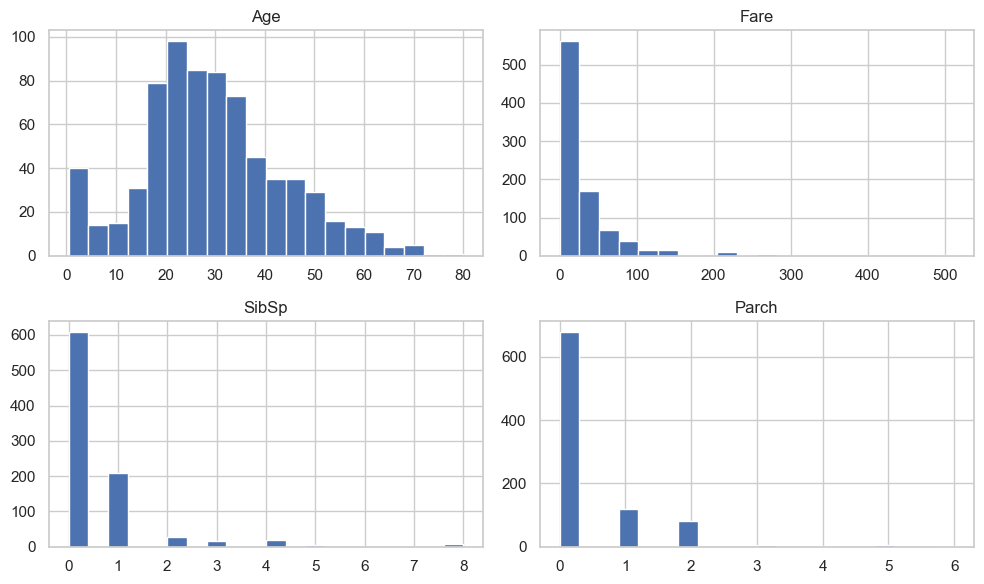

TypeError: subplot() takes 1 or 3 positional arguments but 2 were given

<Figure size 800x500 with 0 Axes>

In [6]:
# Histograms (already given)
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]
df[numeric_cols].hist(bins=20, figsize=(10, 6))
plt.tight_layout()
plt.show()


cat_cols = ["Sex","Pclass", "Embarked"]

fig, axes = plt.subplot(1,3 , figsize=(14, 4))

for i, col in enumerate(cat_cols):
    sns.countplot(x=col,data=df, ax=axes[i],palette='Set2')
    axes[i].set_title(f"{col} Distribution")



| Code | কী করছে |
|------|---------|
| `.hist(bins=20)` | প্রতিটা numeric column এর frequency distribution দেখাচ্ছে |
| `fig, axes = plt.subplots(1, 3)` | একসাথে ৩টা chart পাশাপাশি বানাচ্ছে |
| `for i, col in enumerate(cat_cols)` | list এর index ও value একসাথে loop করছে |
| `ax=axes[i]` | কোন subplot এ chart আঁকবে সেটা বলছে |

Markdown cell এ লেখো:
```
- Insight 1:
  Age histogram এ দেখা যায় ২০-৩০ বছর বয়সী যাত্রী সবচেয়ে বেশি।
  শিশু যাত্রীর সংখ্যাও উল্লেখযোগ্য।

- Insight 2:
  Fare এর distribution অনেক right-skewed — বেশিরভাগ যাত্রী
  কম দামের টিকেট কিনেছেন, কিন্তু কিছু যাত্রী অনেক বেশি দাম দিয়েছেন।

- Insight 3:
  Sex chart এ দেখা যায় male যাত্রী female এর প্রায় দ্বিগুণ।
  Pclass এ 3rd class যাত্রী সবচেয়ে বেশি।

## CHATGPT
তুমি যে অংশটা বলছো:

```python
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
```

এখানে **দুইটা variable (`fig` এবং `axes`)** আছে কারণ **Matplotlib** এর `subplots()` ফাংশন **দুইটা জিনিস return করে**।

---

# ১️⃣ `fig` কী?

`fig` মানে **Figure**।

এটা পুরো graph window বা canvas।

সহজভাবে:

```
Figure (fig)
 ├─ Graph 1
 ├─ Graph 2
 └─ Graph 3
```

মানে পুরো ছবিটা।

---

# ২️⃣ `axes` কী?

`axes` মানে **individual graphs** (প্রতিটা plot)।

তুমি যেহেতু `1,3` দিয়েছো তাই ৩টা axes তৈরি হবে।

```
axes[0] → Graph 1
axes[1] → Graph 2
axes[2] → Graph 3
```

---

# ৩️⃣ তাই দুইটা variable লাগে

কারণ function return করে:

```python
fig, axes
```

মানে

* `fig` → পুরো figure
* `axes` → প্রতিটা plot

---

# ৪️⃣ কেন `axes[i]` ব্যবহার করা হচ্ছে

এই লাইনে দেখো:

```python
sns.countplot(x=col, data=df, ax=axes[i])
```

এখানে

```
i = 0 → axes[0] → প্রথম graph
i = 1 → axes[1] → দ্বিতীয় graph
i = 2 → axes[2] → তৃতীয় graph
```

তাই loop দিয়ে তিনটা graph আঁকা হচ্ছে।

---

# 📊 Visual Example

ধরো output হবে:

```
+-------------+-------------+-------------+
| Sex Plot    | Pclass Plot | Embarked    |
|             |             | Plot        |
+-------------+-------------+-------------+
```

এটা পুরোটা `fig`

আর প্রতিটা box হলো `axes`.

---

✅ **Short answer**

দুইটা variable লাগে কারণ:

```
plt.subplots() → returns (figure, axes)
```

---




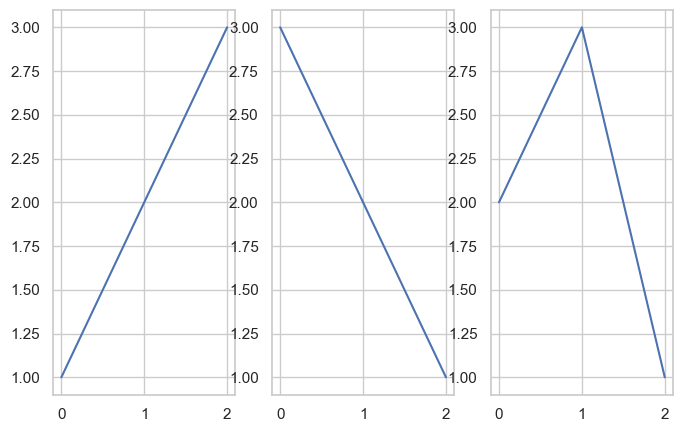

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3)

axes[0].plot([1,2,3])
axes[1].plot([3,2,1])
axes[2].plot([2,3,1])

plt.show()

## 3. Bivariate Analysis with Target
### 🎯 কী শিখবো?
দুটো variable এর মধ্যে সম্পর্ক দেখা — বিশেষত প্রতিটা feature কীভাবে Survived এর সাথে সম্পর্কিত।
### 🔍 উদ্দেশ্য কী?
কোন features গুলো prediction এ সবচেয়ে কাজে আসবে সেটা বোঝা।

KeyboardInterrupt: 

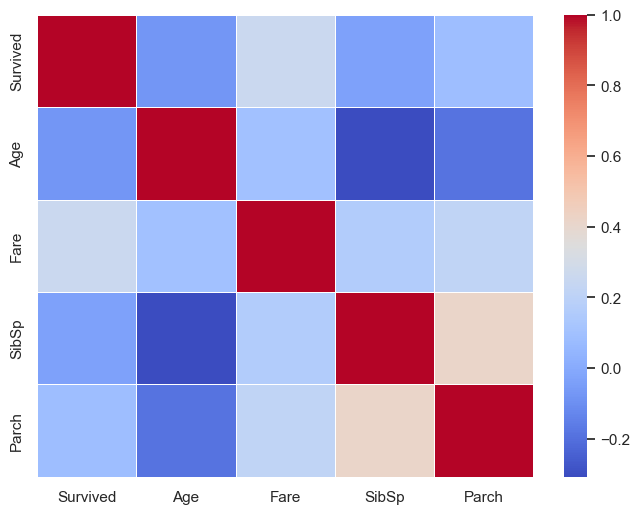

In [40]:
num_for_corr = ["Survived", "Age", "Fare", "SibSp", "Parch"]

plt.figure(figsize=(8,6))
sns.heatmap(
    df[num_for_corr].corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

sns.pairplot(df[num_for_corr], hue='Survived', palette='Set2', corner=True)
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.show()

| Code | কী করছে |
|------|---------|
| `df[num_for_corr].corr()` | নির্দিষ্ট columns এর মধ্যে correlation matrix বানাচ্ছে |
| `annot=True` | প্রতিটা cell এ correlation সংখ্যা লিখছে |
| `fmt=".2f"` | ২ দশমিক পর্যন্ত দেখাচ্ছে |
| `sns.pairplot(...)` | প্রতিটা feature pair এর scatter plot একসাথে দেখাচ্ছে |
| `hue='Survived'` | Survived অনুযায়ী রঙ আলাদা করছে |
| `corner=True` | শুধু নিচের অর্ধেক দেখাচ্ছে (উপরে mirror তাই বাদ) |

Markdown cell এ লেখো:
```
- Insight 1:
  Fare ও Survived এর মধ্যে positive correlation আছে —
  বেশি দামের টিকেট কেনা যাত্রীরা বেশি বেঁচেছেন।

- Insight 2:
  Age ও Survived এর সম্পর্ক খুব কম — মানে বয়স একা
  survival নির্ধারণ করেনি।

- Insight 3:
  Pairplot এ দেখা যায় Fare বেশি হলে Survived=1 (সবুজ)
  বেশি — এটা Pclass এর সাথে সম্পর্কিত।

তুমি যে পুরো কোডটা দিয়েছো সেটা **Data Visualization** করার জন্য। এখানে **Correlation Heatmap** এবং **Pairplot** ব্যবহার করা হয়েছে। এগুলো সাধারণত **Seaborn** এবং **Matplotlib** দিয়ে করা হয়।

এখন ধাপে ধাপে সহজ বাংলায় বুঝি। 👇

---

# 1️⃣ Column নির্বাচন

```python
num_for_corr = ["Survived", "Age", "Fare", "SibSp", "Parch"]
```

এখানে dataset থেকে কিছু **numeric column** নেওয়া হয়েছে।

এইগুলো হলো:

* **Survived** → যাত্রী বেঁচেছিল কিনা
* **Age** → বয়স
* **Fare** → টিকিটের দাম
* **SibSp** → sibling/spouse সংখ্যা
* **Parch** → parent/child সংখ্যা

👉 এই ৫টা feature দিয়ে analysis হবে।

---

# 2️⃣ Correlation Heatmap

## Figure size

```python
plt.figure(figsize=(8, 6))
```

Graph এর **size 8×6** করা হয়েছে।

---

## Heatmap তৈরি

```python
sns.heatmap(
    df[num_for_corr].corr(),
```

### `df[num_for_corr]`

dataset থেকে শুধু ওই ৫টা column নেওয়া হচ্ছে।

### `.corr()`

এটা **correlation matrix** তৈরি করে।

Correlation value:

| Value | Meaning                  |
| ----- | ------------------------ |
| +1    | strong positive relation |
| 0     | no relation              |
| -1    | strong negative relation |

---

## Number দেখানো

```python
annot=True
```

প্রতিটা box এর ভিতরে **correlation value দেখাবে**।

---

## Decimal format

```python
fmt=".2f"
```

২ decimal পর্যন্ত দেখাবে।

Example:

```
0.34
-0.21
```

---

## Color theme

```python
cmap='coolwarm'
```

Color map:

* **Blue → negative correlation**
* **Red → positive correlation**

---

## Grid line

```python
linewidths=0.5
```

Box এর মাঝে **line তৈরি করে**।

---

## Title দেওয়া

```python
plt.title("Correlation Heatmap")
```

Graph এর উপরে **title দেখাবে**।

---

## Layout ঠিক করা

```python
plt.tight_layout()
```

Graph এর elements overlap না করার জন্য spacing ঠিক করে।

---

## Graph দেখানো

```python
plt.show()
```

Plot screen এ দেখাবে।

---

# 3️⃣ Pairplot

```python
sns.pairplot(df[num_for_corr], hue='Survived', palette='Set2', corner=True)
```

**Pairplot** হলো এমন graph যেখানে সব feature এর **pairwise relationship** দেখা যায়।

### `df[num_for_corr]`

এই ৫টা column ব্যবহার করা হচ্ছে।

---

### `hue='Survived'`

Data কে **Survived অনুযায়ী color করা হবে**।

* 0 → Not survived
* 1 → Survived

---

### `palette='Set2'`

Color style সেট করা হয়েছে।

---

### `corner=True`

সব graph না দেখিয়ে শুধু **lower triangle graph দেখাবে**।

এতে plot **clean এবং readable হয়**।

---

## Pairplot title

```python
plt.suptitle("Pairplot of Numeric Features", y=1.02)
```

Pairplot এর উপরে title বসানো হয়েছে।

`y=1.02` দিলে title একটু উপরে যায়।

---

## Plot show

```python
plt.show()
```

Graph display করবে।

---

# 📊 এই কোডের কাজ সংক্ষেপে

এই কোড:

1️⃣ Titanic dataset এর কিছু numeric feature নেয়
2️⃣ তাদের **correlation heatmap তৈরি করে**
3️⃣ তারপর **pairplot দিয়ে feature relationship visualize করে**

---

✅ **Heatmap → feature relation strength দেখায়**
✅ **Pairplot → feature distribution এবং relationship দেখায়**

---

👍 চাইলে আমি তোমাকে আরও দেখাতে পারি:

* **Pairplot কিভাবে interpret করতে হয় (data science interview trick)**
* **Titanic dataset full EDA step-by-step**
* **10টা important seaborn plots (data science এ সবচেয়ে বেশি লাগে)**


# Part B: Preprocessing

## 5. Missing Values Handle করা
### 🎯 কী শিখবো?
কোন column এ কতটা missing, এবং ধরন অনুযায়ী সঠিক imputation method বেছে নেওয়া।
### 🔍 উদ্দেশ্য কী?
Missing value রেখে দিলে ML model error দেয় বা ভুল শেখে।

In [46]:
print("Missing values before:")
print(df.isna().sum())

# Drop Cabin
df = df.drop('Cabin', axis=1 ,errors='ignore')

# Fill Age — numeric তাই Median দিয়ে
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

# Fill Embarked — categorical তাই Mode দিয়ে
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

print("\nMissing values after handling:")
print(df.isna().sum())

Missing values before:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Missing values after handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


| Code | কী করছে |
|------|---------|
| `df.isna().sum()` | প্রতিটা column এ কতটা missing |
| `df['Age'].median()` | Age এর মধ্যমান (outlier এর প্রভাব কম) |
| `df['Age'].fillna(age_median)` | missing Age গুলো median দিয়ে fill |
| `df['Embarked'].mode()[0]` | সবচেয়ে বেশিবার আসা port |

Markdown cell এ লেখো:
```
- Why you dropped Cabin:
  Cabin এ ৭৭% এরও বেশি data missing। এত বেশি missing
  থাকলে imputation করলে data misleading হয়, তাই drop করাই ভালো।

- Why Median for Age:
  Age এ outlier থাকতে পারে (খুব বৃদ্ধ যাত্রী)।
  Mean outlier দ্বারা প্রভাবিত হয়, কিন্তু Median হয় না।
  তাই Age এর জন্য Median বেশি উপযুক্ত।

- Why Mode for Embarked:
  Embarked categorical variable। Text data এর
  mean বা median হয় না। সবচেয়ে common category
  (Mode) দিয়ে fill করাই সঠিক পদ্ধতি।

এই কোডটা মূলত dataset এর **missing values (NaN)** খুঁজে বের করা এবং সেগুলো handle করার জন্য। সাধারণত এটা **Data Science** এবং **Pandas** দিয়ে করা হয়।

আমি ধাপে ধাপে সহজ বাংলায় বুঝাচ্ছি। 👇

---

# 1️⃣ Missing values চেক করা

```python
print("Missing values before:")
print(df.isna().sum())
```

### `df.isna()`

এটা dataset এর প্রতিটা cell চেক করে:

* যদি value না থাকে → **True**
* যদি value থাকে → **False**

উদাহরণ:

| Age | Fare |
| --- | ---- |
| 22  | 7.25 |
| NaN | 8.05 |

`isna()` করলে:

| Age   | Fare  |
| ----- | ----- |
| False | False |
| True  | False |

---

### `.sum()`

`True = 1` ধরা হয়।

তাই `.sum()` করলে **প্রতিটা column এ কতগুলো missing value আছে সেটা বের হয়**।

Example output:

```
Age         177
Cabin       687
Embarked      2
```

---

# 2️⃣ Cabin column drop করা

```python
df = df.drop('Cabin', axis=1)
```

এখানে **Cabin column পুরোপুরি remove করা হচ্ছে**।

### কেন?

Titanic dataset এ **Cabin column এ অনেক বেশি missing value থাকে**।

### `axis=1`

* `axis=0` → row
* `axis=1` → column

তাই এখানে **column delete করা হচ্ছে**।

---

# 3️⃣ Age fill করা (Median দিয়ে)

```python
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
```

### `median()`

Median মানে **middle value**।

উদাহরণ:

```
10, 20, 30, 40, 50
```

Median = **30**

### কেন Median ব্যবহার করা হয়?

Age numeric data।
Median ব্যবহার করলে **outlier এর effect কম হয়**।

---

# 4️⃣ Embarked fill করা (Mode দিয়ে)

```python
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
```

### Embarked কি?

Passenger কোন port থেকে উঠেছে।

Example:

* C → Cherbourg
* Q → Queenstown
* S → Southampton

এটা **categorical data**।

---

# 5️⃣ `mode()[0]` explain

এটা গুরুত্বপূর্ণ।

### `mode()`

Mode মানে **সবচেয়ে বেশি বার যে value আসে**।

Example:

```
S, S, S, C, Q
```

Mode = **S**

---

কিন্তু **Pandas এর `mode()` list/series return করে**।

Example:

```python
df['Embarked'].mode()
```

Output:

```
0    S
dtype: object
```

তাই প্রথম value নেওয়ার জন্য লিখতে হয়:

```python
mode()[0]
```

### সহজভাবে

```
mode() → সবচেয়ে বেশি value এর list
[0] → সেই list এর প্রথম value
```

---

# 6️⃣ Missing values fill করা

```python
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
```

এটা **Embarked column এর সব NaN কে mode দিয়ে replace করে**।

Example:

Before:

```
S
C
NaN
S
```

After:

```
S
C
S
S
```

---

# 7️⃣ আবার missing values check করা

```python
print("\nMissing values after handling:")
print(df.isna().sum())
```

এখানে আবার check করা হচ্ছে।

Expected output:

```
Age        0
Embarked   0
Cabin      0
```

মানে **সব missing values handle হয়ে গেছে**।

---

# 📊 পুরো কোডের কাজ

এই কোড:

1️⃣ Dataset এ missing values count করে
2️⃣ Cabin column remove করে
3️⃣ Age → median দিয়ে fill করে
4️⃣ Embarked → mode দিয়ে fill করে
5️⃣ শেষে আবার check করে

---

✅ **Interview tip (Data Science):**

Numeric data → **Median / Mean**
Categorical data → **Mode**

---

👍 চাইলে আমি তোমাকে আরও শেখাতে পারি:

* **`fillna()` এর 5টা advanced trick**
* **Data cleaning complete roadmap**
* **Titanic dataset EDA + ML model step-by-step** (beginner → advanced)


# 6. Categorical Encoding — OneHotEncoder
## 🎯 কী শিখবো?
OneHotEncoder দিয়ে categorical variable কে multiple binary column এ বদলানো।
## 🔍 উদ্দেশ্য কী?
ML model সংখ্যা বোঝে। Sex, Embarked, Pclass text বা number হলেও এদের মধ্যে কোনো mathematical order নেই — তাই OneHotEncoding করতে হবে।

### 💡 OneHotEncoding vs LabelEncoding পার্থক্য

| বিষয় | Label Encoding | One-Hot Encoding |
|-----|-----|-----|
| কী করে | male = 0, female = 1 | প্রতিটি category এর জন্য আলাদা column তৈরি করে |
| সমস্যা | Model মনে করতে পারে male < female (order আছে) | কোনো order বা ranking ধরে না |
| কখন ব্যবহার | Binary category (২টা value) | ৩ বা তার বেশি categories |



In [7]:
df_enc = df.copy()

cat_features = ["Sex", "Embarked", "Pclass"]
numeric_features = ["Age", "Fare", "SibSp", "Parch"]
target_col = "Survived"

# OneHotEncoder apply করা
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_array = ohe.fit_transform(df_enc[cat_features])
encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(cat_features)
)

# Final DataFrame বানানো
df_model = pd.concat([
    df_enc[[target_col] + numeric_features].reset_index(drop=True),
    encoded_df.reset_index(drop=True)
], axis=1)

print("Shape after encoding:", df_model.shape)
display(df_model.head())

Shape after encoding: (891, 11)


,Survived,Age,Fare,SibSp,Parch,Sex_male,Embarked_Q,Embarked_S,Embarked_nan,Pclass_2,Pclass_3
0,0,22.0,7.2500,1,0,1.0,0.0,1.0,0.0,0.0,1.0
1,1,38.0,71.2833,1,0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,26.0,7.9250,0,0,0.0,0.0,1.0,0.0,0.0,1.0
3,1,35.0,53.1000,1,0,0.0,0.0,1.0,0.0,0.0,0.0
4,0,35.0,8.0500,0,0,1.0,0.0,1.0,0.0,0.0,1.0


ঠিক আছে! চলুন ধাপে ধাপে তোমার কোডটা **Python** এবং **Data Science / Machine Learning preprocessing** এর context-এ বাংলায় ব্যাখ্যা করি। আমি পুরো workflow-টা পরিষ্কার করে দেখাব। 👇

---

# 1️⃣ Copy Dataset

```python
df_enc = df.copy()
```

* এখানে আমরা **original dataset `df` এর copy** তৈরি করছি।
* কারণ আমরা চাই **original data safe থাকুক**, যাতে encoding বা transformation করলে মূল dataset change না হয়।

---

# 2️⃣ Feature সেট করা

```python
cat_features = ["Sex", "Embarked", "Pclass"]
numeric_features = ["Age", "Fare", "SibSp", "Parch"]
target_col = "Survived"
```

* **cat_features → categorical features** (যেগুলো সংখ্যা নয়, যেমন Sex, Embarked)
* **numeric_features → সংখ্যাগত features** (Age, Fare ইত্যাদি)
* **target_col → model এর target variable** (যাকে predict করতে হবে, এখানে Survived)

---

# 3️⃣ One-Hot Encoding করা

```python
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_array = ohe.fit_transform(df_enc[cat_features])
```

### ব্যাখ্যা:

* **OneHotEncoder** (from `sklearn.preprocessing`) categorical data কে **numerical format** এ convert করে।
* **sparse_output=False** → matrix কে **normal numpy array** হিসেবে চাই।
* **drop='first'** → প্রথম category drop করে **dummy variable trap** এড়ায়।

Example:

```text
Sex
male
female
```

One-Hot Encoding:

| Sex_male | Sex_female |
| -------- | ---------- |
| 1        | 0          |
| 0        | 1          |

যদি drop='first' হয় → **Sex_male column drop করা হয়**।

* এখন শুধুই Sex_female থাকবে, male automatically infer করা যাবে।

* `fit_transform(df_enc[cat_features])` → **encoder কে data অনুযায়ী train এবং transform একসাথে**।

---

# 4️⃣ Encoded DataFrame তৈরি

```python
encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(cat_features)
)
```

* `encoded_array` → OneHotEncoder থেকে পাওয়া numpy array।
* `columns=ohe.get_feature_names_out(cat_features)` → **proper column names set করা**, যেমন Sex_female, Embarked_Q, Pclass_2 ইত্যাদি।

---

# 5️⃣ Final DataFrame বানানো

```python
df_model = pd.concat([
    df_enc[[target_col] + numeric_features].reset_index(drop=True),
    encoded_df.reset_index(drop=True)
], axis=1)
```

### ব্যাখ্যা:

* `df_enc[[target_col] + numeric_features]` → **original numeric + target columns নেওয়া**।
* `encoded_df` → **categorical column গুলো যা One-Hot Encoding হয়েছে**।
* `reset_index(drop=True)` → index ঠিক রাখা।
* `pd.concat(..., axis=1)` → **columns-wise merge** করা।

এভাবে তৈরি হয়েছে **model-ready dataset**। এখন সব column numeric।

---

# 6️⃣ Shape এবং Preview দেখা

```python
print("Shape after encoding:", df_model.shape)
display(df_model.head())
```

* `shape` → (rows, columns)
* `display(df_model.head())` → প্রথম ৫টি row দেখাবে

উদাহরণ output:

| Survived | Age | Fare | SibSp | Parch | Sex_male | Embarked_Q | Embarked_S | Pclass_2 | Pclass_3 |
| -------- | --- | ---- | ----- | ----- | -------- | ---------- | ---------- | -------- | -------- |
| 0        | 22  | 7.25 | 1     | 0     | 1        | 0          | 1          | 0        | 1        |

---

# ✅ Summary of this Code

1. Dataset copy করা → safety।
2. Categorical এবং numeric features আলাদা করা।
3. **One-Hot Encoding** → categorical → numeric।
4. Column names ঠিক করা।
5. Numeric + encoded columns merge করা → **model-ready dataframe**।
6. Shape এবং first 5 rows দেখানো।

---

💡 **Important Notes / ML Tips**

* LabelEncoding শুধু **ordinal data** (যেখানে order আছে) বা **binary category** এর জন্য use করা হয়।
* OneHotEncoding **nominal data / 3+ categories** এর জন্য best।
* `drop='first'` → avoid dummy variable trap (multicollinearity problem)।

---

যদি চাও আমি তোমাকে **এই dataset দিয়ে পুরো ML model training step-by-step Python এ শেখাতে পারি**, যেমন:

* Train/Test split
* Scaling / normalization
* Logistic Regression / Random Forest model
* Accuracy, confusion matrix, evaluation

এটা করলে তুমি পুরো Titanic ML pipeline বুঝে যাবে।

---

তুমি কি চাইছো আমি সেই full ML pipeline তৈরি করে দেখাই next?


# 7. Feature Scaling
### 🎯 কী শিখবো?
StandardScaler দিয়ে numeric features এর range সমান করা এবং before/after boxplot তুলনা।
### 🔍 উদ্দেশ্য কী?
Age (0-80) আর Fare (0-512) এর range অনেক আলাদা। Distance-based model (KNN, SVM) এ Fare অনেক বেশি গুরুত্বপূর্ণ মনে হবে — Scaling করলে সব feature সমান গুরুত্ব পায়।

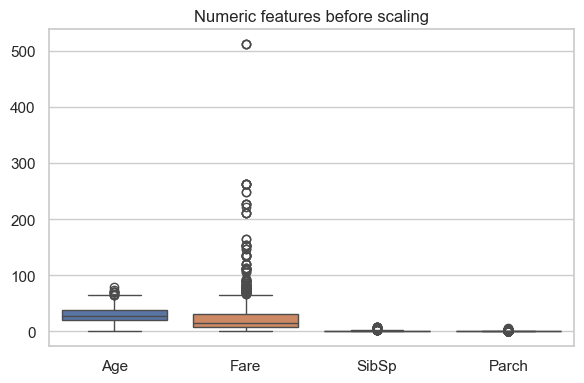

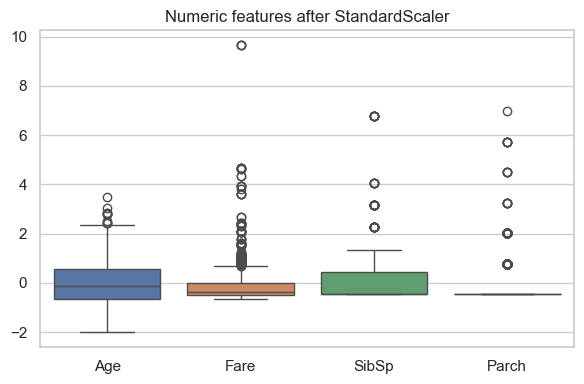

In [9]:
score_cols = ["Age", "Fare", "SibSp", "Parch"]

# Boxplot before scaling (already given)
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_model[score_cols])
plt.title("Numeric features before scaling")
plt.tight_layout()
plt.show()

# StandardScaler apply করা (তোমাকে করতে হবে)
scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[score_cols] = scaler.fit_transform(df_model[score_cols])

# Boxplot after scaling (already given)
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_scaled[score_cols])
plt.title("Numeric features after StandardScaler")
plt.tight_layout()
plt.show()

চলো একদম সহজভাবে, ধাপে ধাপে বাংলায় পুরো জিনিসটা বুঝি—Python + এই কোডটা কী করছে সব 👍

---

# 🔹 Python কী? (একদম সহজ ভাষায়)

Python হলো একটা **programming language**, যেটা দিয়ে তুমি:

* data analysis করতে পারো 📊
* machine learning করতে পারো 🤖
* website বানাতে পারো 🌐
* automation করতে পারো ⚙️

👉 সহজভাবে:
Python = “কম্পিউটারকে দিয়ে কাজ করানোর ভাষা”

---

# 🔹 এখন তোমার কোডটা কী করছে?

এই কোডটা **data preprocessing + visualization** করছে।

আমরা Titanic dataset টাইপ কিছু data নিয়ে কাজ করছি ধরে নাও।

---

# 🧩 Step 1: Column select করা

```python
score_cols = ["Age", "Fare", "SibSp", "Parch"]
```

👉 এখানে আমরা বলছি:
এই ৪টা column নিয়ে কাজ করবো

| Column | মানে                     |
| ------ | ------------------------ |
| Age    | বয়স                      |
| Fare   | টিকিট দাম                |
| SibSp  | সাথে কয়জন sibling/spouse |
| Parch  | সাথে কয়জন parent/child   |

---

# 📊 Step 2: Scaling এর আগে Boxplot

```python
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_model[score_cols])
plt.title("Numeric features before scaling")
plt.show()
```

👉 এখানে কী হচ্ছে?

* `sns.boxplot()` → data এর distribution দেখাচ্ছে
* কোন column এর value বেশি/কম spread সেটা দেখা যায়

👉 সমস্যা:

* Fare অনেক বড় value হতে পারে
* SibSp ছোট value

➡️ মানে scale আলাদা

---

# ⚠️ কেন সমস্যা?

ধরো:

* Fare = 500
* SibSp = 2

👉 Machine learning algorithm বলবে:
👉 "Fare বেশি important" (কারণ value বড়)

❌ এটা ভুল হতে পারে

---

# 🔧 Step 3: StandardScaler apply করা

```python
scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[score_cols] = scaler.fit_transform(df_model[score_cols])
```

এটা খুব important part 👇

---

## 🧠 `StandardScaler()` কী?

👉 এটা প্রতিটা column কে normalize করে:

genui{"math_block_widget_always_prefetch_v2":{"content":"z = \frac{x - \mu}{\sigma}"}}

👉 মানে:

* mean (average) = 0
* standard deviation = 1

---

## 🔍 Line by line:

### ✅ `scaler = StandardScaler()`

👉 scaler object তৈরি

---

### ✅ `df_scaled = df_model.copy()`

👉 original data নষ্ট না করার জন্য copy

---

### ✅ `fit_transform()`

```python
scaler.fit_transform(df_model[score_cols])
```

👉 এটা ২টা কাজ করে:

1. **fit()** → mean, std হিসাব করে
2. **transform()** → data scale করে

---

### ✅ Assign করা

```python
df_scaled[score_cols] = ...
```

👉 scaled value আবার ওই column এ বসানো

---

# 📊 Step 4: Scaling এর পরে Boxplot

```python
sns.boxplot(data=df_scaled[score_cols])
```

👉 এখন কী হবে?

* সব column same range এ আসবে
* comparison fair হবে

---

# 🧠 খুব গুরুত্বপূর্ণ concept (Exam/Interview ⭐)

## ✅ Sentence 1 (তোমার markdown এর মতো)

StandardScaler প্রতিটা numeric feature এর mean 0 এবং
standard deviation 1 করে দেয়, ফলে সব feature একই scale এ আসে।

---

## ✅ Sentence 2

KNN বা SVM এর মতো distance-based algorithm এ
scaling না করলে বড় range এর feature (যেমন Fare)
ছোট range এর feature (যেমন SibSp) কে dominate করে
ভুল result দেয়।

---

# 🔥 Real-life analogy (সবচেয়ে সহজভাবে)

ধরো তুমি compare করছো:

* Height (cm) → 170
* Weight (kg) → 60

👉 Height বড় মনে হচ্ছে, কিন্তু আসলে না

➡️ তাই normalize করা দরকার

---

# 🎯 এক লাইনে পুরো কোডের কাজ

👉 “Numeric data গুলোকে same scale এ এনে, আগে ও পরে visualization দেখানো”

---

# 💡 Extra (Pro Tip)

Scaling দরকার হয় যখন:

* KNN ✅
* SVM ✅
* Logistic Regression ✅
* Neural Network ✅

Scaling দরকার হয় না:

* Decision Tree ❌
* Random Forest ❌

---

তুমি চাইলে আমি এটা **diagram দিয়ে** বা **real dataset দিয়ে step-by-step run করে দেখাতে পারি** 👍


# 8. Final Quality Check
### 🎯 কী শিখবো?
পুরো preprocessing শেষে dataset ML এর জন্য ready কিনা verify করা।
### 🔍 উদ্দেশ্য কী?
Model এ data দেওয়ার আগে নিশ্চিত করা — কোনো missing নেই, সব numeric, সব ঠিকঠাক।

In [11]:
# (already given)
print(df_scaled.info())
print("\nTotal missing values in final DataFrame:", df_scaled.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Survived      891 non-null    int64  
 1   Age           714 non-null    float64
 2   Fare          891 non-null    float64
 3   SibSp         891 non-null    float64
 4   Parch         891 non-null    float64
 5   Sex_male      891 non-null    float64
 6   Embarked_Q    891 non-null    float64
 7   Embarked_S    891 non-null    float64
 8   Embarked_nan  891 non-null    float64
 9   Pclass_2      891 non-null    float64
 10  Pclass_3      891 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 76.7 KB
None

Total missing values in final DataFrame: 177
